In [1]:
# path = "/lustre/LHCb/carlos.arenas/data/v009_pb-pb-pmu0.0018-fn0k-fc0-ww3_inelastic_none_1_1e6.hepmc"
# path = "/lustre/LHCb/carlos.arenas/data/v009_pb-pb-pmu0.0018-fn0k-fc0-ww3_inelastic_none_1_1e6.hepmc"

path = "/lustre/LHCb/carlos.arenas/data/v009_pmu7-fn0k-fc0-ww3_inelastic_none_1_1e4.hepmc"

In [22]:
with open(path, "r") as file:
    lines = file.readlines()

event_lines = []
for i, line in enumerate(lines):
    values = line.split(" ")

    if values[0] == "E":
        event_id = int(values[1])
        event_lines.append([event_id, i])

event_lines.append([0, len(lines) - 1])

print(f"Hay {len(event_lines) - 1} eventos")

Hay 90 eventos


In [4]:
import sys
sys.path.insert(0, "cobra/src")           # so Python can find the cobra package
from cobra import load_detector_from_yaml

detector = load_detector_from_yaml("/lustre/LHCb/carlos.arenas/cobra/config/codex-beta.yaml")

/lustre/LHCb/carlos.arenas/cobra/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pyhepmc
import numpy as np
from cobra import StripDecoder
from cobra.geometry import transform_surface
from cobra.geometry import strip_to_global_position


# Unused
"""
def strip_points(detector, strips):
    points = []
    for module_id in {int(r[0]) for r in strips}:       # go module by module...
        module = detector.modules[module_id]
        for slot in range(3):                           # ...and singlet by singlet within the module
            here = [r for r in strips if int(r[0]) == module_id and int(r[1]) == slot]
            phi_strips = [int(r[2]) for r in here if int(r[4]) == 0]
            eta_strips = [int(r[2]) for r in here if int(r[4]) == 1]
            singlet = detector.singlets[module.singlet_ids[slot]]
            for phi in phi_strips:
                for eta in eta_strips:
                    point = strip_to_global_position(detector, module, singlet, eta_strip=eta, phi_strip=phi)
                    points.append(point)
                    # print(phi, eta, point)

    return [np.array(points_module) for points_module in points]
"""    

def strip_points_module_singlet(detector, strips, row_ids):
    points = []
    module_singlets = []
    new_row_ids = []

    # print(f"lens: {len(strips)}, {len(row_ids)}")

    for module_id in {int(r[0]) for r in strips}:       # go module by module...
        module = detector.modules[module_id]
        for slot in range(3):                           # ...and singlet by singlet within the module
            here = {row_ids[i]: strips[i] for i in range(len(strips)) if int(strips[i][0]) == module_id and int(strips[i][1]) == slot}
            phi_strips = {row_id: int(strip[2]) for row_id, strip in here.items() if int(strip[4]) == 0}
            eta_strips = {row_id: int(strip[2]) for row_id, strip in here.items() if int(strip[4]) == 1}
            singlet = detector.singlets[module.singlet_ids[slot]]
            for row_id_phi, phi in phi_strips.items():
                for row_id_eta, eta in eta_strips.items():
                    point = strip_to_global_position(detector, module, singlet, eta_strip=eta, phi_strip=phi)
                    points.append(point)
                    module_singlets.append([module_id, slot])

                    new_row_ids.append([row_id_phi, row_id_eta])
                    
    return np.array(points), module_singlets, new_row_ids

def get_hit_points(event):
    rows = []
    raw_banks_id = []
    for key, value in event.attributes.items():
        if key.startswith("RawBank_"):
            raw_bank_id = key.split("_")[-1]
            module, strip, time0, time1 = [int(x) for x in str(value).split()]

            rows.append([0, module, strip, time0, time1])           # 0 = sourceID placeholder
            raw_banks_id.append(int(raw_bank_id))

    raw_banks = np.array(rows, dtype=np.int16)

    strips = []
    new_raw_banks_id = []

    for i, raw_bank in enumerate(raw_banks):
        current_strips = StripDecoder()._process(np.array([raw_bank]))
        for strip in current_strips:
            strips.append(strip)
            new_raw_banks_id.append(raw_banks_id[i])

    raw_banks_id = new_raw_banks_id

    # strips = StripDecoder()._process(raw_banks)

    points, module_singlets, new_raw_banks_id = strip_points_module_singlet(detector, strips, raw_banks_id)

    return points, module_singlets, new_raw_banks_id

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_detector(ax, view = "front", zoom = "zoom_in"):
    for module in detector.modules.values():
        corners = np.vstack([transform_surface(detector, module, detector.singlets[s]) for s in module.singlet_ids])
        lo, hi = corners.min(axis=0), corners.max(axis=0)
        if view == "front":
            ax.add_patch(plt.Rectangle((lo[0], lo[1]), hi[0] - lo[0], hi[1] - lo[1], facecolor="lightgreen", alpha=0.3))
        elif view == "side":
            ax.add_patch(plt.Rectangle((lo[0], lo[2]), hi[0] - lo[0], hi[2] - lo[2], facecolor="lightgreen", alpha=0.3))

    ax.set_xlabel("x [m]")
    ax.set_box_aspect(1)

    if view == "front":
        ax.set_ylabel("y [m]");
        if zoom == "zoom_in":
            ax.set_xlim(left= 29, right= 33)
            ax.set_ylim(bottom= -6, top= -3)
        elif zoom == "zoom_medium":
            ax.set_xlim(left= 25, right= 33)
            ax.set_ylim(bottom= -6, top= -2)
        elif zoom == "zoom_out":
            ax.set_xlim(left=-10, right=32)
            ax.set_ylim(bottom=-10, top=25)
        elif zoom == "zooom_in":
            ax.set_xlim(left= 29.7, right= 29.9)
            ax.set_ylim(bottom= -5.3, top= -5)
    if view == "side":
        ax.set_ylabel("z [m]");
        if zoom == "zoom_out":
            ax.set_xlim(left=-10, right=32)
            ax.set_ylim(bottom=-10, top=25)
        elif zoom == "zoom_in":
            ax.set_xlim(left=29, right=33)
            ax.set_ylim(bottom=7, top=11)

In [7]:
def cov(X, Y):
    return sum((X - np.mean(X))*(Y - np.mean(Y)))

def lineal_regression(X, Y):
    # lmq -> y = mx + n
    m = cov(X,Y)/cov(X,X)
    n = np.mean(Y) - m*np.mean(X)

    err = Y - m*X - n
    R = 1 - np.dot(err, err)/cov(Y, Y)

    return m, n, R

In [8]:
def match_hits_particles(raw_banks_id):
    # Match points with particles
    # points[i] <-> points_particle[i]

    global raw_banks_particles

    global points_particle
    points_particle.clear()

    points_particle = []
    for phi_id, eta_id in raw_banks_id:
        particle_id = raw_banks_particles[phi_id]
        if particle_id == raw_banks_particles[eta_id]:
            points_particle.append(particle_id)
        else:
            points_particle.append(None)

def sort_points_by_module():
    global event
    
    global hit_points
    global sorted_points_id

    hit_points, module_singlets, raw_banks_id = get_hit_points(event)
    print(f"Hay: {len(hit_points)} puntos")

    # sort points by module, singlet:
    sorted_points_id.clear()
    modules = {module_singlet[0] for module_singlet in module_singlets}
    for module in modules:
        sorted_points_id.append([[],[],[]])
        for i, P in enumerate(hit_points):
            if module_singlets[i][0] == module:
                sorted_points_id[-1][module_singlets[i][1]].append(i)

    match_hits_particles(raw_banks_id)

In [51]:
def group_inside_modules(sorted_points_id):
    global hit_points

    clusters = []
    min_distance = 0.003
    for module_points in sorted_points_id:
        module_selected_points = [0]*sum([len(x) for x in module_points])

        for i, id1 in enumerate(module_points[0]):
            if not module_selected_points[i]:
                P1 = hit_points[id1]

                d2_min = min_distance
                for j, id2 in enumerate(module_points[1]):
                    if not module_selected_points[j + len(module_points[0])]:
                        P2 = hit_points[id2]

                        d2_ij = np.dot((P2 - P1), (P2 - P1))
                        if d2_ij < d2_min:
                            d2_min = d2_ij

                    if d2_min < min_distance:
                        d2_min = min_distance
                        for k, id3 in enumerate(module_points[2]):
                            if not module_selected_points[k + len(module_points[0]) + len(module_points[1])]:
                                P3 = hit_points[id3]

                                d2_ij = np.dot((P3 - P2), (P3 - P2))
                                if d2_ij < d2_min:
                                    d2_min = d2_ij

                                if d2_min < min_distance:
                                    # print("Hola", i, j + len(module_points[0]), k + len(module_points[0]) + len(module_points[1]))

                                    X = np.array([P1, P2, P3])
                                    my, ny, Ry = lineal_regression(X[:,0], X[:,1])
                                    mz, nz, Rz = lineal_regression(X[:,0], X[:,2])

                                    if Ry > 0.7 and Rz > 0.7:
                                        clusters.append([id1, id2, id3])
                                        # module_selected_points[i] = 1
                                        # module_selected_points[j + len(module_points[0])] = 1
                                        # module_selected_points[k + len(module_points[0]) + len(module_points[1])] = 1

                                    break
    return clusters

In [10]:
def fill_dicc():
    global event_nr
    global particle_links
    global raw_banks_particles

    particle_links.clear()
    raw_banks_particles.clear()

    for line in lines[event_lines[event_nr][1]:event_lines[event_nr + 1][1]]:
        values = line.split()

        if values[0] == "A":
            if values[2] == "RawBankLinks":
                particle_id = int(values[1])
                particle_links[particle_id] = [int(x) for x in values[3:]]

                for x in values[3:]:
                    raw_banks_particles[abs(int(x))] = particle_id

            elif values[2].startswith("RawBank_"):
                raw_bank_id = int(values[2].split("_")[-1])
                raw_bank = [int(x) for x in values[3:]]

                raw_banks[raw_bank_id] = raw_bank

def plot_something():
    global hit_points

    fig, axs = plt.subplots(2)
    plot_detector(axs[0], zoom = "zooom_in")
    axs[0].scatter(hit_points[:,0], hit_points[:,1])

    plot_detector(axs[1], view = "side", zoom = "zoom_in")
    axs[1].scatter(hit_points[:,0], hit_points[:,2])
    plt.show()

In [11]:
def calc_ef(clusters):
    global points_particle

    global ef_counter
    global total_counter

    for cluster in clusters:
        same_particle = True
        for point_id in cluster[1:]:
            if points_particle[point_id] != points_particle[cluster[0]]:
                same_particle = False

        if same_particle:
            ef_counter += 1
        total_counter += 1

In [ ]:
def plot_event(ax, hit_points):
    ax.scatter(hit_points)
    plt.show()

In [102]:
def track_particles(clusters, hit_points):
    if len(clusters) <= 1: return
    print(f"Hay: {len(clusters)} clústeres")

    chi2_min = 0.1
    all_chis = []
    for i, c1 in enumerate(clusters):
        for j, c2 in enumerate(clusters[i+1:]):

            X = []
            for P_idx in c1 + c2:
                X.append(hit_points[P_idx])

            X = np.array(X)
            my, ny, Ry = lineal_regression(X[:,0], X[:,1])
            mz, nz, Rz = lineal_regression(X[:,0], X[:,2])

            # errx = X[:,0] 
            chi2 = 2 - Ry - Rz
            if chi2 < 0.05:
                all_chis.append(chi2)
    
    # plt.hist(all_chis, bins = 50, range = (0,0.05))
    # plt.show()

In [12]:
def next_event():
    global event_it
    global event
    global event_nr

    try:
        event = next(it)
        event_nr += 1
    except StopIteration:
        raise StopIteration

In [111]:
def clustering_method(hit_points):
    clusters = []
    n_points = len(hit_points)

    visited = [0]*n_points

    def visit(idx):
        if not visited[idx]:
            for i in range(n_points - idx - 1):
                j = i + idx + 1

                PQ = hit_points[j] - hit_points[idx]

                if np.dot(PQ, PQ) < 0.003:
                    clusters[-1].append(j)
                    visited[j] = 1
                    visit(j)


    for i in range(n_points):
        if not visited[i]:
            clusters.append([i])
            visit(i)

    return clusters

In [134]:
def group_clusters(clusters):
    cluster_groups = []
    groups_chi2 = []
    for i, c1 in enumerate(clusters):
        for j_, c2 in enumerate(clusters[i+1:]):
            j = j_ + i + 1
            for k_, c3 in enumerate(clusters[j+1:]):
                k = k_ + j + 1

                global hit_points
                X = np.array([hit_points[idx] for idx in c1 + c2 + c3])

                my, ny, Ry = lineal_regression(X[:,0], X[:,1])
                mz, nz, Rz = lineal_regression(X[:,0], X[:,2])

                chi2 = 2 - Ry - Rz

                if chi2 < 0.01:
                    cluster_groups.append([i, j, k])
                    groups_chi2.append(chi2)

    return cluster_groups, groups_chi2

def extend_cluster_groups(clusters, cluster_groups, groups_chi2):
    for i, cluster_group in enumerate(cluster_groups):
        for j, cluster in enumerate(clusters):
            if j not in cluster_group:

                global hit_points
                X = np.array([hit_points[idx] for idx in sum([clusters[cluster_id] for cluster_id in cluster_group], []) + cluster])

                my, ny, Ry = lineal_regression(X[:,0], X[:,1])
                mz, nz, Rz = lineal_regression(X[:,0], X[:,2])

                chi2 = 2 - Ry - Rz

                if chi2 < 0.01:
                    cluster_groups[i].append(j)
                    groups_chi2[i] = chi2

    return cluster_groups, groups_chi2

In [140]:
def plot_cluster_groups(cluster_groups, clusters):
    fig, ax = plt.subplots()

    global hit_points
    X = np.array(hit_points)
    ax.scatter(X[:,0], X[:,1])

    for cluster_group in cluster_groups:
        Y = []
        for cluster_id in cluster_group:
            for P_idx in clusters[cluster_id]:
                Y.append(hit_points[P_idx])

        Y = np.array(Y)
        my, ny, Ry = lineal_regression(Y[:,0], Y[:,1])

        a = min(Y[:,0])
        b = max(Y[:,0])

        e = 0.1*(b-a)
        a -= e
        b += e

        ax.plot([a,b], my*np.array([a,b]) + ny)

    plt.show()

# Unused
def get_chi2(X: np.ndarray):
    my, ny, Ry = lineal_regression(X[:,0], X[:,1])
    mz, nz, Rz = lineal_regression(X[:,0], X[:,2])

    chi2 = 2 - Ry - Rz

    return chi2

def reject_cluster_groups(clusters, cluster_groups, groups_chi2):
    new_cluster_groups = []
    new_chi2s = []

    for c_id, c in enumerate(clusters):
        min_chi2 = 2
        current_cluster_group = -1
        for i, cluster_group in enumerate(cluster_groups):
            if c_id in cluster_group:
                if groups_chi2[i] < min_chi2:
                    min_chi2 = groups_chi2[i]
                    current_cluster_group = i

        if min_chi2 < 2:
            if not current_cluster_group in new_cluster_groups:
                new_cluster_groups.append(current_cluster_group)
                new_chi2s.append(min_chi2)

    return [cluster_groups[x] for x in new_cluster_groups], new_chi2s
            

Hay: 14 puntos
Clústeres:
[[0, 1, 2, 3, 5], [4, 5], [6, 7, 8, 9], [10, 11, 12, 13]]
Hay: 4 clústeres
Cluster groups:
[[0, 1, 3, 2], [0, 2, 3, 1], [1, 2, 3, 0]]
Cluster groups:
[[0, 1, 3, 2]]
Lengths: 4, 1
Chis: [np.float64(0.005840040409857528)]


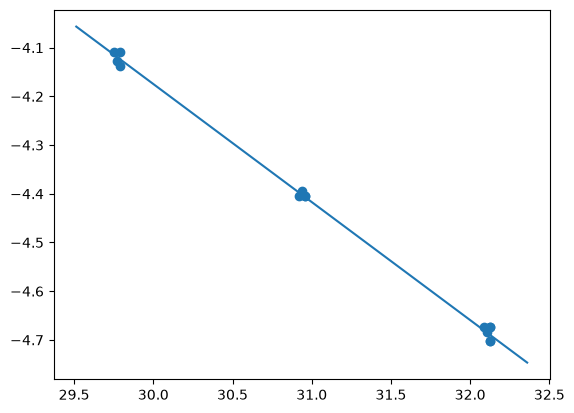

4 4
Hay: 377 puntos
Clústeres:
[[0, 4, 28, 32, 57, 59, 62, 64, 66, 69, 92, 97, 116, 151, 158, 159, 160], [1, 2, 3, 29, 30, 31, 56, 63, 91], [5, 33, 60, 61, 67, 68, 95, 96, 115, 150, 157], [6, 30, 34], [7, 11, 21, 25, 28, 32, 57, 71, 73, 76, 92, 94, 97, 109, 110, 111, 151], [8, 9, 10, 22, 23, 24, 29, 30, 31, 70, 91], [12, 26, 33, 60, 74, 75, 95, 96, 108, 150], [13, 23, 27, 30, 34], [14, 18, 49, 53, 78, 85, 90, 137], [15, 16, 17, 50, 51, 52, 84], [19, 54, 81, 88, 89, 136], [20, 51, 55], [35, 39, 78, 80, 83, 130, 131, 132, 137], [36, 37, 38, 77], [40, 81, 82, 129, 136], [41], [42, 46, 49, 53, 85, 87, 90, 99, 101, 104, 123, 124, 125, 144], [43, 44, 45, 50, 51, 52, 84, 98], [47, 54, 88, 89, 102, 103, 122, 143], [48, 51, 55], [58, 63, 65, 91, 93, 105, 112, 147, 149, 154, 156], [72, 91, 93, 105, 107, 147], [79, 126, 128, 133, 135], [86, 98, 100, 119, 121, 140], [106, 111, 148, 153], [113, 118, 155, 160], [114, 154, 156], [117, 158, 159], [120, 125, 141, 146], [127, 132, 134, 139], [138], [142

/tmp/ipykernel_4169383/2789375322.py:6: RuntimeWarning: invalid value encountered in scalar divide
  m = cov(X,Y)/cov(X,X)
/tmp/ipykernel_4169383/2789375322.py:10: RuntimeWarning: invalid value encountered in scalar divide
  R = 1 - np.dot(err, err)/cov(Y, Y)


Cluster groups:
[[0, 80, 81], [1, 78, 79, 3], [2, 80, 81], [3, 26, 78, 79], [3, 78, 79, 1], [5, 78, 79], [6, 80, 81], [7, 78, 79], [8, 12, 72, 29, 30, 45, 73, 74], [8, 12, 73, 29, 45, 72, 74], [8, 16, 72, 28, 32, 73, 74], [8, 16, 73, 28, 72, 74], [8, 28, 72, 16, 32, 73, 74], [8, 28, 73, 16, 72, 74], [8, 29, 72, 12, 30, 45, 73, 74], [8, 29, 73, 12, 45, 72, 74], [8, 30, 72, 12, 29, 45, 73, 74], [8, 30, 73, 12, 45, 72, 74], [8, 30, 74, 45, 72, 73], [8, 30, 76], [8, 30, 80, 32, 81], [8, 30, 81, 32, 80], [8, 31, 72, 73, 74], [8, 31, 73, 72, 74], [8, 32, 72, 16, 28, 73, 74], [8, 32, 73, 16, 72, 74], [8, 32, 80, 30, 81], [8, 32, 81, 30, 80], [8, 45, 72, 12, 29, 30, 73, 74], [8, 45, 73, 12, 29, 30, 72, 74], [8, 45, 74, 30, 72, 73], [8, 49, 72, 30, 32, 73, 74], [8, 49, 73, 30, 32, 72, 74], [8, 72, 73, 12, 29, 30, 31, 45, 74], [8, 72, 74, 12, 29, 30, 45, 49, 73], [8, 73, 74, 12, 29, 30, 45, 49, 72], [8, 80, 81, 12, 30], [9, 11, 72, 13, 15, 73, 74], [9, 11, 73, 13, 72, 74], [9, 11, 74, 19, 72, 73

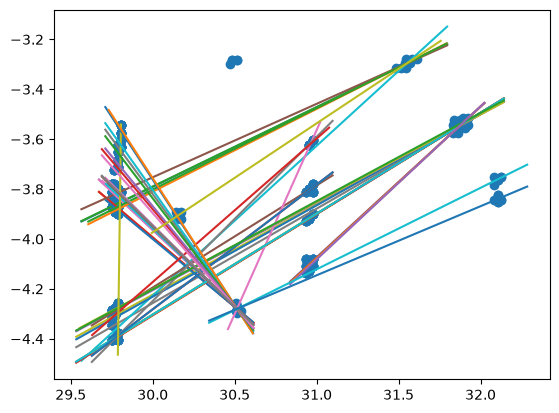

63 86
Hay: 13 puntos
Clústeres:
[[0, 1, 2, 5], [3, 4, 5, 6], [7, 8, 9, 11, 12], [10, 11, 12]]
Hay: 4 clústeres
Cluster groups:
[]
Cluster groups:
[]
Lengths: 4, 0
Chis: []


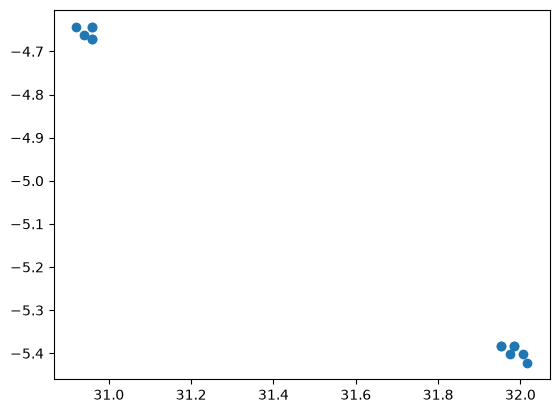

67 90
Hay: 29 puntos
Clústeres:
[[0, 1, 3, 4, 8, 11], [2, 4, 5, 6, 7, 8, 9, 10, 11, 12], [13, 15, 17, 18, 20], [14], [16, 18, 19], [21, 22, 23, 24, 25, 26, 28], [27, 28]]
Hay: 7 clústeres
Cluster groups:
[[0, 1, 5, 2, 6], [0, 2, 5, 1, 6], [0, 2, 6, 5], [0, 3, 5, 2, 4, 6], [0, 3, 6, 5], [0, 4, 5, 1, 6], [0, 5, 6, 1, 2, 3, 4], [1, 2, 5, 0, 6], [1, 3, 5, 2, 4, 6], [1, 4, 5, 0, 6], [1, 5, 6, 0, 2, 3, 4], [2, 3, 5, 0, 4, 6], [2, 3, 6, 5], [2, 4, 5, 0, 3, 6], [2, 4, 6, 5], [2, 5, 6, 0, 1, 3, 4], [3, 4, 5, 0, 2, 6], [4, 5, 6, 0, 1, 2, 3]]
Cluster groups:
[[0, 2, 6, 5], [0, 1, 5, 2, 6], [0, 3, 6, 5], [2, 4, 6, 5]]
Lengths: 7, 4
Chis: [np.float64(0.00465227905469856), np.float64(0.007827082456333345), np.float64(0.005454013789464085), np.float64(0.0049338338541821125)]


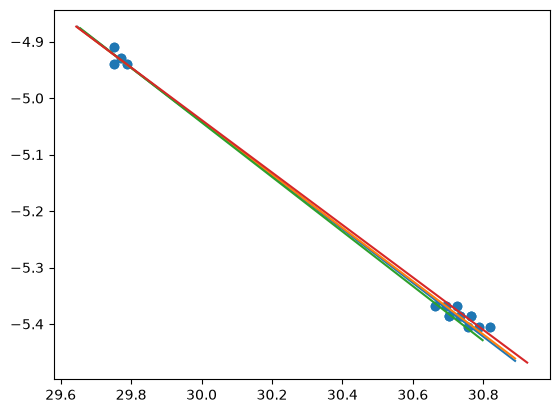

74 97
Hay: 6 puntos
Clústeres:
[[0, 1, 2, 3, 4, 5]]
Cluster groups:
[]
Cluster groups:
[]
Lengths: 1, 0
Chis: []


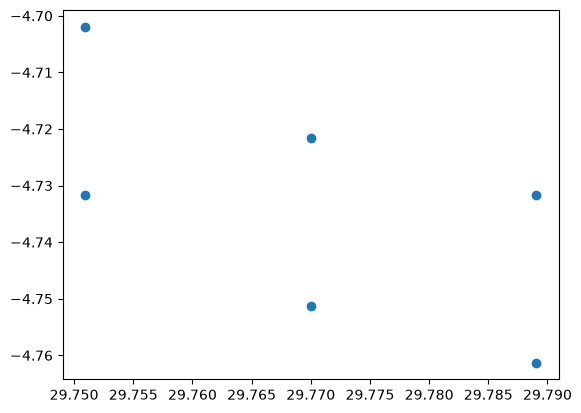

75 98
Hay: 14 puntos
Clústeres:
[[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11, 13], [12, 13]]
Hay: 4 clústeres
Cluster groups:
[]
Cluster groups:
[]
Lengths: 4, 0
Chis: []


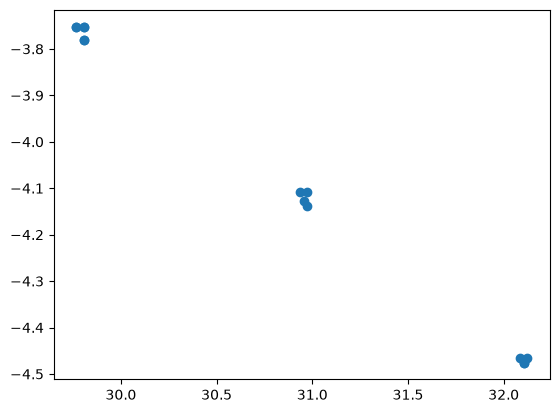

79 102
Hay: 30 puntos
Clústeres:
[[0, 1, 4, 5], [2, 3, 5, 6, 7, 8, 9, 11], [10, 12, 13, 14, 17, 18], [15, 16, 17, 18, 19], [20, 21, 22], [23, 24, 25, 26, 27, 28], [29]]
Hay: 7 clústeres
Cluster groups:
[[0, 1, 5, 2, 3, 4, 6], [0, 2, 5, 1, 3, 4, 6], [0, 3, 5, 1, 2, 4, 6], [0, 4, 5, 1, 2, 3, 6], [0, 4, 6, 5], [0, 5, 6, 1, 2, 3, 4], [1, 2, 5, 0, 3, 4, 6], [1, 3, 5, 0, 2, 4, 6], [1, 4, 5, 0, 2, 3, 6], [1, 5, 6, 0, 2, 3, 4], [2, 3, 5, 0, 1, 4, 6], [2, 4, 5, 0, 1, 3, 6], [2, 5, 6, 0, 1, 3, 4], [3, 4, 5, 0, 1, 2, 6], [3, 4, 6, 5], [3, 5, 6, 0, 1, 2, 4]]
Cluster groups:
[[0, 4, 6, 5], [0, 1, 5, 2, 3, 4, 6], [3, 4, 6, 5]]
Lengths: 7, 3
Chis: [np.float64(0.005790817268774395), np.float64(0.007774347913300783), np.float64(0.00554774955331816)]


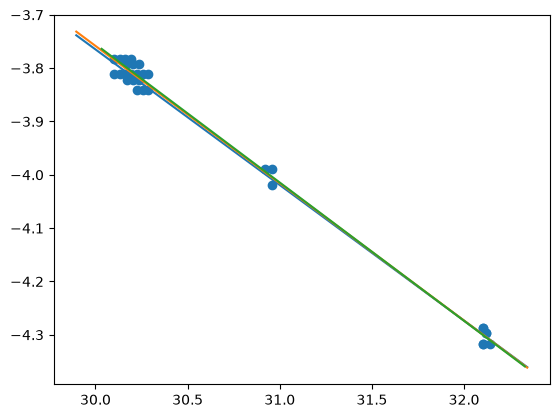

86 109
Hay: 12 puntos
Clústeres:
[[0, 1, 2], [3, 4, 5, 6, 7], [8, 9, 10, 11]]
Hay: 3 clústeres
Cluster groups:
[[0, 1, 2]]
Cluster groups:
[[0, 1, 2]]
Lengths: 3, 1
Chis: [np.float64(0.004761059564842518)]


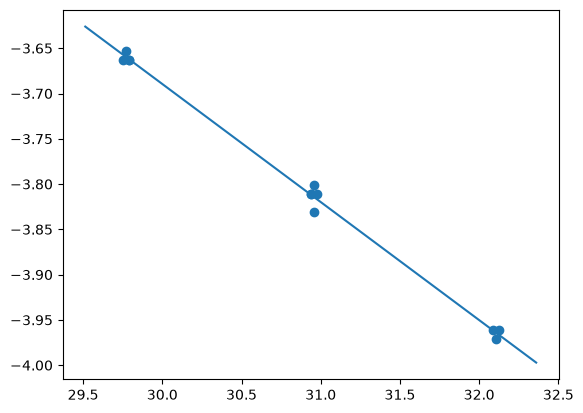

89 112
Hay: 24 puntos
Clústeres:
[[0, 1, 3, 4], [2, 4, 5, 10, 11, 16, 17, 22, 23], [6, 7, 11, 18, 19, 23], [8, 9, 19, 20, 21], [12, 13, 17, 18, 19, 23], [14, 15, 19, 20, 21]]
Hay: 6 clústeres
Cluster groups:
[]
Cluster groups:
[]
Lengths: 6, 0
Chis: []


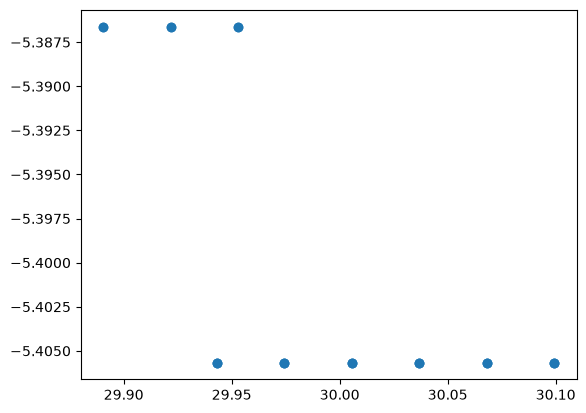

95 118
Hay: 26 puntos
Clústeres:
[[0, 1, 2, 3, 4, 5, 6], [7, 8, 10, 11, 13, 14], [9, 11, 12, 13, 14, 16], [15, 17], [18, 19, 20, 21, 23], [22, 23, 24, 25]]
Hay: 6 clústeres
Cluster groups:
[[0, 1, 2, 3, 4, 5], [0, 1, 3, 2, 4, 5], [0, 1, 4, 2, 3, 5], [0, 1, 5, 2, 3, 4], [0, 2, 3, 1, 4, 5], [0, 2, 4, 1, 3, 5], [0, 2, 5, 1, 3, 4], [0, 3, 4, 1, 2, 5], [0, 3, 5, 1, 2, 4], [0, 4, 5, 1, 2, 3], [1, 3, 4, 0, 2, 5], [1, 3, 5, 0, 2, 4], [1, 4, 5, 0, 2, 3], [2, 3, 4, 0, 1, 5]]
Cluster groups:
[[0, 1, 3, 2, 4, 5]]
Lengths: 6, 1
Chis: [np.float64(0.0024401317746560736)]


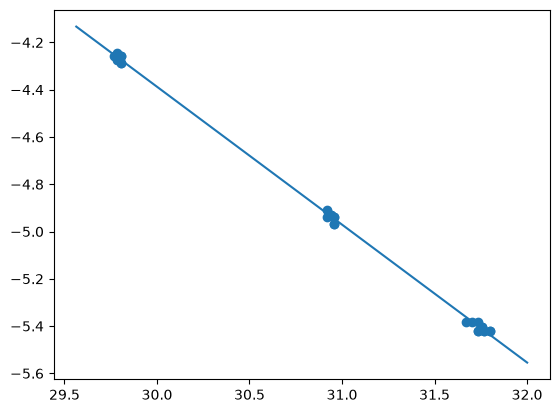

101 124


In [142]:
event_nr = -1

raw_banks = {}

particle_links = {}
raw_banks_particles = {}

hit_points = []
sorted_points_id = []

points_particle = {}

ef_counter = 0
total_counter = 0

# ==========

cluster_sizes = []

# ==========

with pyhepmc.open(path) as f:
    event_it = iter(f)

    for i in range(10):
        try:
            event = next(event_it)
            event_nr += 1
        except StopIteration:
            break

        fill_dicc()
        sort_points_by_module()

        clusters = group_inside_modules(sorted_points_id)
        clusters = clustering_method(hit_points)
        print("Clústeres:")
        print(clusters)

        calc_ef(clusters)

        track_particles(clusters, hit_points)

        for c in clusters:
            cluster_sizes.append(len(c))

        cluster_groups, groups_chi2 = group_clusters(clusters)
        cluster_groups, groups_chi2 = extend_cluster_groups(clusters, cluster_groups, groups_chi2)

        print("Cluster groups:")
        print(cluster_groups)

        cluster_groups, groups_chi2 = reject_cluster_groups(clusters, cluster_groups, groups_chi2)
        
        print("Cluster groups:")
        print(cluster_groups)



        print(f"Lengths: {len(clusters)}, {len(cluster_groups)}")
        print(f"Chis: {groups_chi2}")

        plot_cluster_groups(cluster_groups, clusters)
        

        # cluster_groups = extend_cluster_groups(cluster_groups, clusters)

        print(ef_counter, total_counter)


5.17741935483871


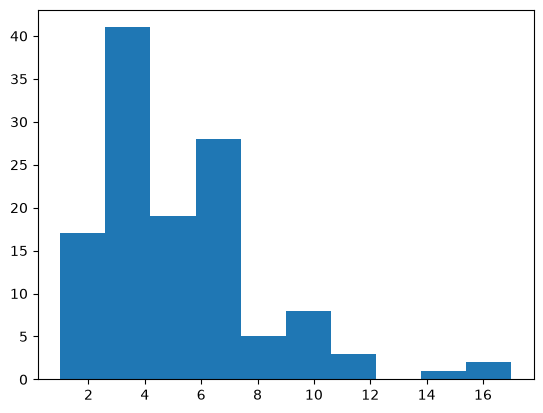

In [81]:
print(sum(cluster_sizes)/len(cluster_sizes))

plt.hist(cluster_sizes)
plt.show()

In [14]:
print(ef_counter, total_counter)

0 0


41


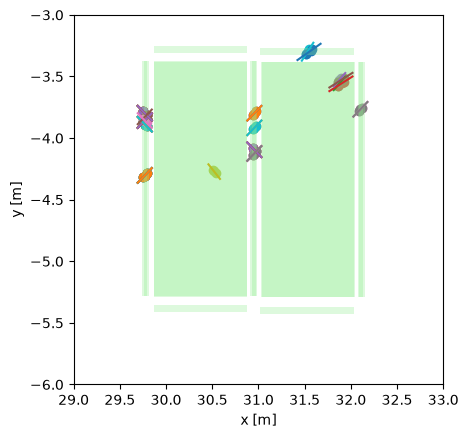

In [ ]:
# print(selected_points)

for cluster in clusters:
    X = np.array([hit_points[point_id] for point_id in cluster])
    plt.scatter(X[:,0], X[:,1])

    m, n, R = lineal_regression(X[:,0], X[:,1])

    a = min(X[:,0])
    b = max(X[:,0])

    e = 1.5*(b-a)
    a -= e
    b += e

    plt.plot([a,b], m*np.array([a,b]) + n)

ax = plt.gca()
plot_detector(ax)

print(len(clusters))

# plt.scatter(X[:,0], X[:,1])
plt.show()

# print(len(module_points))


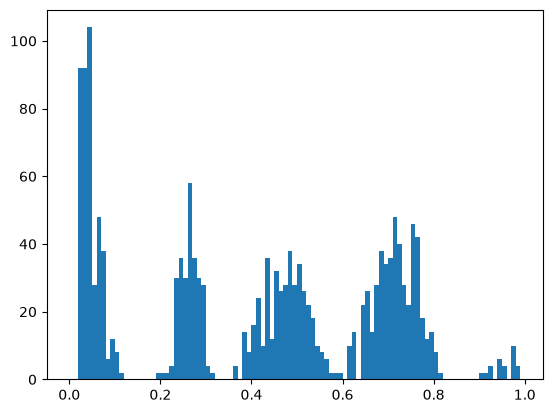

In [75]:
distances = []

for i, P in enumerate(hit_points):
    for j, Q in enumerate(hit_points):
        if i != j:
            PQ = Q - P
            d = np.sqrt(np.dot(PQ,PQ))
            distances.append(d)

fig, ax = plt.subplots()
ax.hist(distances, bins = np.arange(0, 1, 0.01))
plt.show()

In [ ]:
sorted_points = points[points[:, 0].argsort()[::-1]] # Ordena de mayor a menor

print(sorted_points)



[[31.047735   -5.421545    9.37913125]
 [30.859305   -5.386615    9.42850625]
 [30.859305   -5.386615    9.72538125]
 [30.859305   -5.386615    9.45819375]
 [30.849305   -5.367565    9.70569375]
 [30.849305   -5.367565    9.46819375]
 [30.849305   -5.367565    9.43850625]
 [30.828055   -5.386615    9.72538125]
 [30.828055   -5.386615    9.42850625]
 [30.828055   -5.386615    9.45819375]
 [30.818055   -5.367565    9.70569375]
 [30.818055   -5.367565    9.43850625]
 [30.818055   -5.367565    9.46819375]
 [30.786805   -5.367565    9.70569375]
 [30.786805   -5.367565    9.43850625]
 [30.786805   -5.367565    9.46819375]
 [30.755555   -5.367565    9.70569375]
 [30.755555   -5.367565    9.43850625]
 [30.755555   -5.367565    9.46819375]
 [30.161805   -5.405665    9.70569375]
 [30.140555   -5.386615    9.45819375]
 [30.140555   -5.386615    9.42850625]
 [30.140555   -5.386615    9.72538125]
 [30.130555   -5.367565    9.46819375]
 [30.130555   -5.367565    9.43850625]
 [30.130555   -5.367565  